# COSMOS4 boolean-based weight images

COSMOS4 has no inverse-variance weight products. This notebook creates binary validity maps from each calibrated science image. A pixel receives weight 1 only when its science value is finite and nonzero; invalid edge pixels receive weight 0. These files encode coverage only, not inverse variance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'Notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'COSMOS_data' / 'COSMOS4'
BANDS = tuple(f'm{wavelength}' for wavelength in range(400, 900, 25))
science_paths = sorted(DATA_DIR.glob('*.com.fits'))

if len(science_paths) != 16:
    raise RuntimeError(f'Expected 16 COSMOS4 science images, found {len(science_paths)}')

found_bands = tuple(next((band for band in BANDS if f'_{band}_' in path.name), None) for path in science_paths)
if any(band is None for band in found_bands) or len(set(found_bands)) != len(found_bands):
    raise RuntimeError(f'Could not identify unique bands: {found_bands}')

print(f'Data directory: {DATA_DIR}')
print(f'Science images: {len(science_paths)}')
print('Bands:', ', '.join(found_bands))

Data directory: /Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS4
Science images: 16
Bands: m400, m500, m550, m750, m600, m800, m850, m700, m425, m625, m575, m525, m875, m725, m825, m775


## Create weight images

The output filename replaces `.com.fits` with `.weight.fits`. The original WCS/header is retained, while weight provenance is added to the header.

In [2]:
summary_rows = []
footprints = {}

for science_path, band in zip(science_paths, found_bands):
    with fits.open(science_path, memmap=True) as hdul:
        science = np.asarray(hdul[0].data)
        header = hdul[0].header.copy()
        if science.ndim != 2:
            raise ValueError(f'{science_path.name}: expected a 2D image, got {science.shape}')
        valid = np.isfinite(science) & (science != 0)
        n_nan = int(np.isnan(science).sum())
        n_inf = int(np.isinf(science).sum())
        n_zero = int((np.isfinite(science) & (science == 0)).sum())

    weight = valid.astype(np.uint8)
    weight_path = science_path.with_name(science_path.name.replace('.com.fits', '.weight.fits'))
    header['BUNIT'] = ('BOOLEAN', 'Binary coverage weight, not inverse variance')
    header['WGTTYPE'] = ('BOOLEAN', 'Binary validity map')
    header['VALIDDEF'] = ('FINITE&NONZERO', 'Definition of valid science pixels')
    header['NVALID'] = (int(valid.sum()), 'Number of pixels with weight=1')
    header['NINVAL'] = (int((~valid).sum()), 'Number of pixels with weight=0')
    header.add_history(f'Boolean weight generated from {science_path.name}')
    header.add_history('weight=1 where science is finite and nonzero; otherwise weight=0')
    fits.writeto(weight_path, weight, header=header, overwrite=True, checksum=True)

    edge = np.concatenate((weight[0], weight[-1], weight[1:-1, 0], weight[1:-1, -1]))
    y, x = np.where(valid)
    bbox = f'{x.min()}:{x.max()}, {y.min()}:{y.max()}' if len(x) else 'empty'
    summary_rows.append((
        band, science_path.name, weight_path.name, science.shape[1], science.shape[0],
        n_nan, n_inf, n_zero, int(valid.sum()), float(valid.mean()),
        int(edge.sum()), bbox,
    ))
    footprints[band] = weight[::20, ::20]
    print(f'{band}: wrote {weight_path.name} ({valid.mean():.3%} valid)')

summary = Table(
    rows=summary_rows,
    names=('band', 'science_file', 'weight_file', 'nx', 'ny', 'n_nan', 'n_inf',
           'n_zero', 'n_valid', 'valid_fraction', 'outer_edge_valid', 'valid_bbox_x_y'),
)
summary.pprint(max_lines=-1, max_width=-1)

m400: wrote calib_7DT_COSMOS_4_20240526_230501_m400_5400.weight.fits (88.735% valid)


m500: wrote calib_7DT_COSMOS_4_20240526_234330_m500_4200.weight.fits (87.186% valid)


m550: wrote calib_7DT_COSMOS_4_20240526_234702_m550_4560.weight.fits (87.745% valid)


m750: wrote calib_7DT_COSMOS_4_20240526_234734_m750_4560.weight.fits (88.905% valid)


m600: wrote calib_7DT_COSMOS_4_20240526_234739_m600_4920.weight.fits (89.259% valid)


...

m525: wrote calib_7DT_COSMOS_4_20240527_011525_m525_4080.weight.fits (87.378% valid)


m875: wrote calib_7DT_COSMOS_4_20240527_011535_m875_4080.weight.fits (88.982% valid)


m725: wrote calib_7DT_COSMOS_4_20240527_011835_m725_4200.weight.fits (88.687% valid)


m825: wrote calib_7DT_COSMOS_4_20240527_012233_m825_4920.weight.fits (85.477% valid)


m775: wrote calib_7DT_COSMOS_4_20240527_012410_m775_4560.weight.fits (89.029% valid)
band                      science_file                                           weight_file                          nx   ny  n_nan n_inf  n_zero  n_valid    valid_fraction   outer_edge_valid    valid_bbox_x_y  
---- ----------------------------------------------------- -------------------------------------------------------- ----- ---- ----- ----- -------- -------- ------------------ ---------------- -------------------
m400 calib_7DT_COSMOS_4_20240526_230501_m400_5400.com.fits calib_7DT_COSMOS_4_20240526_230501_m400_5400.weight.fits 10200 6800     0     0  7813445 61546555 0.8873494088811995              781    289:9990, 0:6533
m500 calib_7DT_COSMOS_4_20240526_234330_m500_4200.com.fits calib_7DT_COSMOS_4_20240526_234330_m500_4200.weight.fits 10200 6800     0     0  8887723 60472277 0.8718609717416378                0  161:9801, 448:6797
m550 calib_7DT_COSMOS_4_20240526_234702_m550_4560.com.fits cali

## Validate products

In [3]:
weight_paths = sorted(DATA_DIR.glob('*.weight.fits'))
if len(weight_paths) != len(science_paths):
    raise RuntimeError(f'Expected {len(science_paths)} weights, found {len(weight_paths)}')

for science_path in science_paths:
    weight_path = science_path.with_name(science_path.name.replace('.com.fits', '.weight.fits'))
    with fits.open(science_path, memmap=True) as science_hdul, fits.open(weight_path, memmap=True, checksum=True) as weight_hdul:
        science = np.asarray(science_hdul[0].data)
        weight = np.asarray(weight_hdul[0].data)
        expected = np.isfinite(science) & (science != 0)
        if science.shape != weight.shape:
            raise RuntimeError(f'{weight_path.name}: shape mismatch')
        if not np.array_equal(weight, expected.astype(np.uint8)):
            raise RuntimeError(f'{weight_path.name}: data do not match the validity rule')
        if set(np.unique(weight).tolist()) - {0, 1}:
            raise RuntimeError(f'{weight_path.name}: values other than 0 and 1 found')
        if weight_hdul[0].header.get('CHECKSUM') is None:
            raise RuntimeError(f'{weight_path.name}: missing FITS checksum')

print(f'Validation passed: {len(weight_paths)} boolean weight images')

Validation passed: 16 boolean weight images


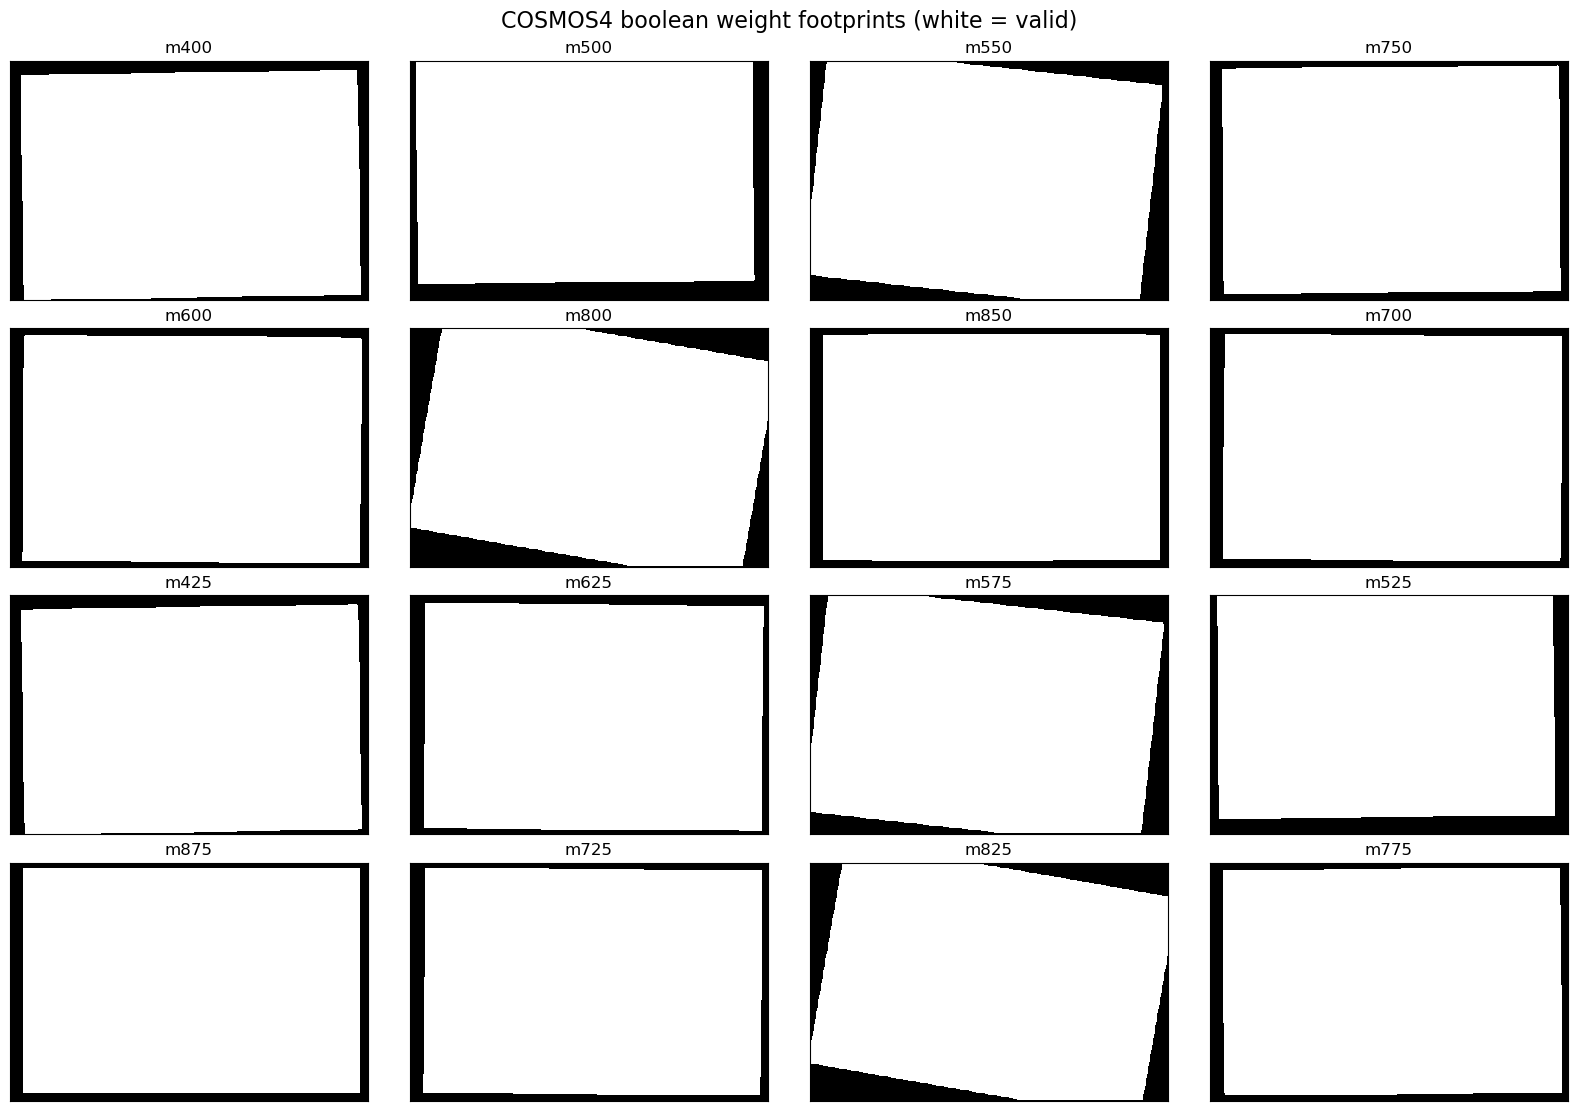

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 11), constrained_layout=True)
for ax, band in zip(axes.flat, found_bands):
    ax.imshow(footprints[band], origin='lower', cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(band)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle('COSMOS4 boolean weight footprints (white = valid)', fontsize=16)
plt.show()